 ## preparation of the decomposed automaton

In [1]:
# generate n chains of length m, where n and m are given by the user, default n = 5, m = 10
# fix some order of the chains
# add dependencies on the edges such that the edge of one chain depends on the states of later chains (not the previous ones in the fixed order)
# the number of states on which a given edge depends is chosen uniformly from {0,1, 2, 3}..if there are multiple states, they need to be from different chains.

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

def gen_chains(n=3, m=10):
    chains = defaultdict(list)

    for i in range(n):
        G = nx.Graph()
        nodes = [j for j in range(m)]
        edges = list(zip(nodes[:-1], nodes[1:]))

        G.add_edges_from(edges)
        chains[i] = G

    return chains

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:
                num_deps = random.randint(0, 3)
                
                if num_deps > 0:
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []
                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})
                    
                    G.edges[edge]['enabling'] = enabling_conditions
    
    return chains

chains = add_enabling(gen_chains())

In [2]:
chains[0][1][2]

{'enabling': [{'automata_id': 1, 'node_id': 2},
  {'automata_id': 2, 'node_id': 8}]}

In [3]:
print(chains[0].edges[(1,2)])

{'enabling': [{'automata_id': 1, 'node_id': 2}, {'automata_id': 2, 'node_id': 8}]}


In [4]:
for chain_id in range(len(chains)):
    print(f"\nChain {chain_id}:")
    G = chains[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")


Chain 0:
Edge 0 -> 1: {'enabling': [{'automata_id': 1, 'node_id': 2}]}
Edge 1 -> 2: {'enabling': [{'automata_id': 1, 'node_id': 2}, {'automata_id': 2, 'node_id': 8}]}
Edge 2 -> 3: {'enabling': [{'automata_id': 2, 'node_id': 6}]}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {}
Edge 8 -> 9: {'enabling': [{'automata_id': 2, 'node_id': 7}]}

Chain 1:
Edge 0 -> 1: {'enabling': [{'automata_id': 2, 'node_id': 6}]}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {'enabling': [{'automata_id': 2, 'node_id': 1}]}
Edge 6 -> 7: {}
Edge 7 -> 8: {'enabling': [{'automata_id': 2, 'node_id': 7}]}
Edge 8 -> 9: {}

Chain 2:
Edge 0 -> 1: {}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {}
Edge 8 -> 9: {}


In [5]:
chains[0].nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9))

## creation of 1 sample problem

In [6]:
# for the fixed order of chains, create a vector of states for each chain. states in different chains are chosen randomly.
# choose 1 chain as the target chain
# choose a random target state in the target chain
# the result is sample = {"input": vector of states, "target": target state, "target chain": target chain}

In [7]:
from itertools import product
def get_vectors(chains):
    states_per_chain = []
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
    
    return list(product(*states_per_chain))

vecs = get_vectors(chains)

In [8]:
from tqdm import tqdm
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

1000it [00:00, 2568465.40it/s]


In [9]:
def get_sample(vector, chains):
    num_chains = len(chains)
    num_states = len(chains[0].nodes())
    
    target_chain = random.randint(0, num_chains-1)

    target_state = random.randint(0, num_states-1)
    
    return {
        'input': list(vector),
        'target_state': target_state,
        'target_chain': target_chain
    }

In [10]:
sample = get_sample(vecs[122], chains)
sample

{'input': [1, 2, 2], 'target_state': 6, 'target_chain': 2}

## implementation of the solver

In [11]:
sample = {'input': [1, 2, 2], 'target_state': 4, 'target_chain': 0}

In [12]:
steps_log = []
shortest_paths_log = []
target_log = []

def get_rule(chains, target_chain, cur_node, next_node):
    cur_rule = chains[target_chain].get_edge_data(cur_node, next_node)
    steps_log.append((target_chain, cur_node, next_node, cur_rule))
    return cur_rule

def get_shortest_path(chains, target_chain, current_state, target_state):
    shortest_path = nx.shortest_path(chains[target_chain],current_state[target_chain], target_state)
    shortest_paths_log.append((target_chain,shortest_path))
    return shortest_path

def solve(sample, chains, path=[]):
    target_chain = sample["target_chain"]
    target_state = sample["target_state"]
    target_log.append((target_chain, target_state))
    current_state = list(sample["input"])
    shortest_paths = get_shortest_path(chains, target_chain, current_state, target_state)
    for i, cur_node in enumerate(shortest_paths):
        if i < len(shortest_paths)-1:
            next_node = shortest_paths[i+1]
            cur_rule = get_rule(chains, target_chain, cur_node, next_node)
            if cur_rule == {}:
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node

                continue
            else:
                for rules in cur_rule["enabling"]:
                    new_sample = {}
                    new_sample['input'] = current_state
                    new_sample["target_state"] = rules["node_id"]
                    new_sample['target_chain'] = rules["automata_id"]
                    path, current_state = solve(new_sample, chains, path)
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                # after each dependency state is resolved, cross the edge and append it to the path and change the current state
                # after the shortest path to the target state if traversed, return the path and the current state
    return path, current_state

    # for the target chain, find all shortest paths from the current state to the target state
    # take the first path and try to traverse it. ie iterate over the edges and do the following:
    # # if the edge is not dependent on other states:
    # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
    # # # path.append(edge)
    # # else get the dependency states, depenendet = edge['enabling']
    # # for each dependency state, do the following:
    # # # new_sample = {}
    # # # new_sample['input_states'] = current_state
    # # # new_sample["target"] = dependency_state
    # # # new_sample['target chain'] = chain of the dependency state
    # # # path, current_state = solve(new_sample,path)
    # # after each dependency state is resolved, cross the edge and append it to the path and change the current state
    # after the shortest path to the target state if traversed, return the path and the current state

In [13]:
solver_path = solve(sample, chains)
solver_path, len(solver_path[0])

(([{'automata_id': 2, 'state_change': (2, 3)},
   {'automata_id': 2, 'state_change': (3, 4)},
   {'automata_id': 2, 'state_change': (4, 5)},
   {'automata_id': 2, 'state_change': (5, 6)},
   {'automata_id': 2, 'state_change': (6, 7)},
   {'automata_id': 2, 'state_change': (7, 8)},
   {'automata_id': 0, 'state_change': (1, 2)},
   {'automata_id': 2, 'state_change': (8, 7)},
   {'automata_id': 2, 'state_change': (7, 6)},
   {'automata_id': 0, 'state_change': (2, 3)},
   {'automata_id': 0, 'state_change': (3, 4)}],
  [4, 2, 6]),
 11)

In [14]:
def group_automata(data):
    changes, finals = data
    result = []
    
    for change in changes:
        if result and result[-1]['automata_id'] == change['automata_id']:
            result[-1]['state_change'].append(change['state_change'])
        else:
            result.append({'automata_id': change['automata_id'], 
                         'state_change': [change['state_change']]})
            
    return (result, finals)

In [15]:
def group_rules(data):
    result = []
    
    for rule in data:
        if result and result[-1]['automata_id'] == rule[0]:
            result[-1]['state_change'].append(((rule[1], rule[2]), rule[3]))
        else:
            result.append({'automata_id': rule[0],  
                         'state_change': [((rule[1], rule[2]), rule[3])]})
            
    return result

In [16]:
rules_grp = group_rules(steps_log)
rules_grp, len(rules_grp)

([{'automata_id': 0,
   'state_change': [((1, 2),
     {'enabling': [{'automata_id': 1, 'node_id': 2},
       {'automata_id': 2, 'node_id': 8}]})]},
  {'automata_id': 2,
   'state_change': [((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6), {}),
    ((6, 7), {}),
    ((7, 8), {})]},
  {'automata_id': 0,
   'state_change': [((2, 3),
     {'enabling': [{'automata_id': 2, 'node_id': 6}]})]},
  {'automata_id': 2, 'state_change': [((8, 7), {}), ((7, 6), {})]},
  {'automata_id': 0, 'state_change': [((3, 4), {})]}],
 5)

In [17]:
path_grp = group_automata(solver_path)
path_grp, len(path_grp[0])

(([{'automata_id': 2,
    'state_change': [(2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]},
   {'automata_id': 0, 'state_change': [(1, 2)]},
   {'automata_id': 2, 'state_change': [(8, 7), (7, 6)]},
   {'automata_id': 0, 'state_change': [(2, 3), (3, 4)]}],
  [4, 2, 6]),
 4)

In [18]:
print([x['automata_id'] for x in rules_grp])
print([x['automata_id'] for x in path_grp[0]])

[0, 2, 0, 2, 0]
[2, 0, 2, 0]


In [19]:
used_rules = []
for x in rules_grp:
    for y in x['state_change']:
        if y[1] != {}:
            used_rules.append((x['automata_id'],y))
for rule in used_rules:
    print(rule)
len(used_rules)

(0, ((1, 2), {'enabling': [{'automata_id': 1, 'node_id': 2}, {'automata_id': 2, 'node_id': 8}]}))
(0, ((2, 3), {'enabling': [{'automata_id': 2, 'node_id': 6}]}))


2

In [20]:
target_log,len(target_log)

([(0, 4), (1, 2), (2, 8), (2, 6)], 4)

In [21]:
def find_origin(condition):
    for rule in used_rules:
        for enabling in rule[1][1]['enabling']:
            if (enabling['automata_id'], enabling['node_id']) == condition:
                return (rule[0], rule[1][0])
            
    return None

***Prepare data for visualization***

In [22]:
# delete row in shortest_paths_log that contains only one instance
shortest_paths_log = [x for x in shortest_paths_log if len(x[1]) > 1]
shortest_paths_log, len(shortest_paths_log)

([(0, [1, 2, 3, 4]), (2, [2, 3, 4, 5, 6, 7, 8]), (2, [8, 7, 6])], 3)

In [32]:
import copy

full_path = []
previous_states = [state for state in sample['input']]
states = [state for state in sample['input']]
rules_grp_tmp = [x for x in rules_grp]

last_automata_id = path_grp[0][0]['automata_id']
last_next_state = path_grp[0][0]['state_change'][0][1]
shortest_paths_log_tmp = [(item[0], [i for i in item[1]]) for item in shortest_paths_log]

# BEGINNING PHASE
# Add steps that only show edges with conditions, no state change
for ruul in rules_grp_tmp:

    if ruul['automata_id'] != path_grp[0][0]['automata_id']:
        rules_grp_tmp = rules_grp_tmp[1:]
        for item in shortest_paths_log_tmp:
            if item[0] == ruul['automata_id'] and item[1] != []:
                current_shortest_path = item[1][:]
                break

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                                'automata_id': ruul['automata_id'],
                                'states': [state for state in states],
                                'next_state': ruul['state_change'][0][0][0],
                                'shortest_path': current_shortest_path,
                                'edge': ruul['state_change'][0][0],
                                'debug_ID': "a",})
    else:
        break

# MAIN PHASE
for rules in path_grp[0]:
    
    # Assign current shortest path
    for item in shortest_paths_log_tmp:
        if item[0] == rules['automata_id'] and item[1] != []:
            current_shortest_path = item[1][:]
            item[1][:len(rules['state_change'])+1] = []
            break

    for i, state_change in enumerate(rules['state_change']):
        # Update state of last automata, needed when switching from one automata to other
        # states[last_automata_id] = last_next_state
        states[rules['automata_id']] = state_change[0]

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path[:],
                            'edge': state_change,
                            'debug_ID': "b",})
        current_shortest_path[:1] = []

        # Look at the upcoming edge if it has a condition
        # if item[1] != [] and state_change[1] == current_shortest_path[-1]:
        #     a = item[1][0]
        #     rule_exists = chains[rules['automata_id']][state_change[1]][a] != {}
        #     current_state_not_target = rules['automata_id'] != sample['target_chain'] or state_change[1] != sample['target_state']
        #     if rule_exists and current_state_not_target:
        #         rule = True
        #         states[rules['automata_id']] = state_change[1]
        #         status = "solving"
        #         solving_rules[rules['automata_id']] = {(state_change[1], a): {target_log_temp[0]: status}}
        #         full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
        #                         'automata_id': rules['automata_id'],
        #                         'states': [state for state in states],
        #                         'next_state': state_change[1],
        #                         'shortest_path': current_shortest_path,
        #                         'edge': (state_change[1], a),
        #                         'conditions': copy.deepcopy(solving_rules),
        #                         'debug_ID': "c",})
        #         target_log_temp = target_log_temp[1:]
        
        last_automata_id = rules['automata_id']
        last_next_state = state_change[1]

    if(len(current_shortest_path) >= 2):

        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path,
                            'edge': (state_change[1], current_shortest_path[1]),
                            'debug_ID': "d",})
    else:
        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'debug_ID': "e",})
        
    # for ruul in rules_grp_tmp:

    #     if ruul['automata_id'] != path_grp[0][0]['automata_id']:
    #         print(ruul['automata_id'])
    #         print(path_grp[0][0]['automata_id'])
            
    #         for item in shortest_paths_log_tmp:
    #             if item[0] == ruul['automata_id'] and item[1] != []:
    #                 current_shortest_path = item[1][:]
    #                 break

    #         full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
    #                                 'automata_id': ruul['automata_id'],
    #                                 'states': [state for state in states],
    #                                 'next_state': ruul['state_change'][0][0][0],
    #                                 'shortest_path': current_shortest_path,
    #                                 'edge': ruul['state_change'][0][0],
    #                                 'debug_ID': "f",})
    #     else:
    #         rules_grp_tmp = rules_grp_tmp[1:]
    #         break

solving_rules = {}
visited = set()

for i, state in enumerate(full_path[0]['states']):
    visited.add((i, state))

# Logic for conditions
for item in full_path:

    if "edge" in item:
        if chains[item['automata_id']].edges[item['edge']] != {}:

            if item['automata_id'] not in solving_rules:
                solving_rules[item['automata_id']] = {}

            if item['edge'] not in solving_rules[item['automata_id']]:
                solving_rules[item['automata_id']][item['edge']] = {}
            
            for condition in chains[item['automata_id']].edges[item['edge']]['enabling']:
                # if (condition['automata_id'], condition['node_id']) not in solving_rules[item['automata_id']][item['edge']]:
                if (condition['automata_id'], condition['node_id']) in visited:
                    val = "solved"
                else:
                    val = "solving"

                solving_rules[item['automata_id']][item['edge']][(condition['automata_id'], condition['node_id'])] = val

    item['conditions'] = copy.deepcopy(solving_rules)

# Last step
# full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
#                             'automata_id': rules['automata_id'],
#                             'states': path_grp[1],
#                             'next_state': state_change[1],})

# full_path, len(full_path)

In [ ]:
def assign_condition(start_index, automata_id, edge, condition):
    val = "solved"
    for item in full_path[::-1]:
        if (item['automata_id'], item['shortest_path'][-1]) == condition:
            val = "solving"
            
        item['conditions'][automata_id][edge][condition] = val

In [46]:
a = [1,2,3,4]
for q in a[::-1]:
    print(q)

4
3
2
1


In [40]:
for x in solving_rules.items():
    print(x)
    


(0, {(1, 2): {(1, 2): 'solved', (2, 8): 'solved'}, (2, 3): {(2, 6): 'solved'}})


In [33]:
full_path

[{'target': {'automata_id': 0, 'state': 4},
  'automata_id': 0,
  'states': [1, 2, 2],
  'next_state': 1,
  'shortest_path': [1, 2, 3, 4],
  'edge': (1, 2),
  'debug_ID': 'a',
  'conditions': {0: {(1, 2): {(1, 2): 'solved', (2, 8): 'solving'}}}},
 {'target': {'automata_id': 0, 'state': 4},
  'automata_id': 2,
  'states': [1, 2, 2],
  'next_state': 3,
  'shortest_path': [2, 3, 4, 5, 6, 7, 8],
  'edge': (2, 3),
  'debug_ID': 'b',
  'conditions': {0: {(1, 2): {(1, 2): 'solved', (2, 8): 'solving'}}}},
 {'target': {'automata_id': 0, 'state': 4},
  'automata_id': 2,
  'states': [1, 2, 3],
  'next_state': 4,
  'shortest_path': [3, 4, 5, 6, 7, 8],
  'edge': (3, 4),
  'debug_ID': 'b',
  'conditions': {0: {(1, 2): {(1, 2): 'solved', (2, 8): 'solving'}}}},
 {'target': {'automata_id': 0, 'state': 4},
  'automata_id': 2,
  'states': [1, 2, 4],
  'next_state': 5,
  'shortest_path': [4, 5, 6, 7, 8],
  'edge': (4, 5),
  'debug_ID': 'b',
  'conditions': {0: {(1, 2): {(1, 2): 'solved', (2, 8): 'solving'

**Visualization**

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


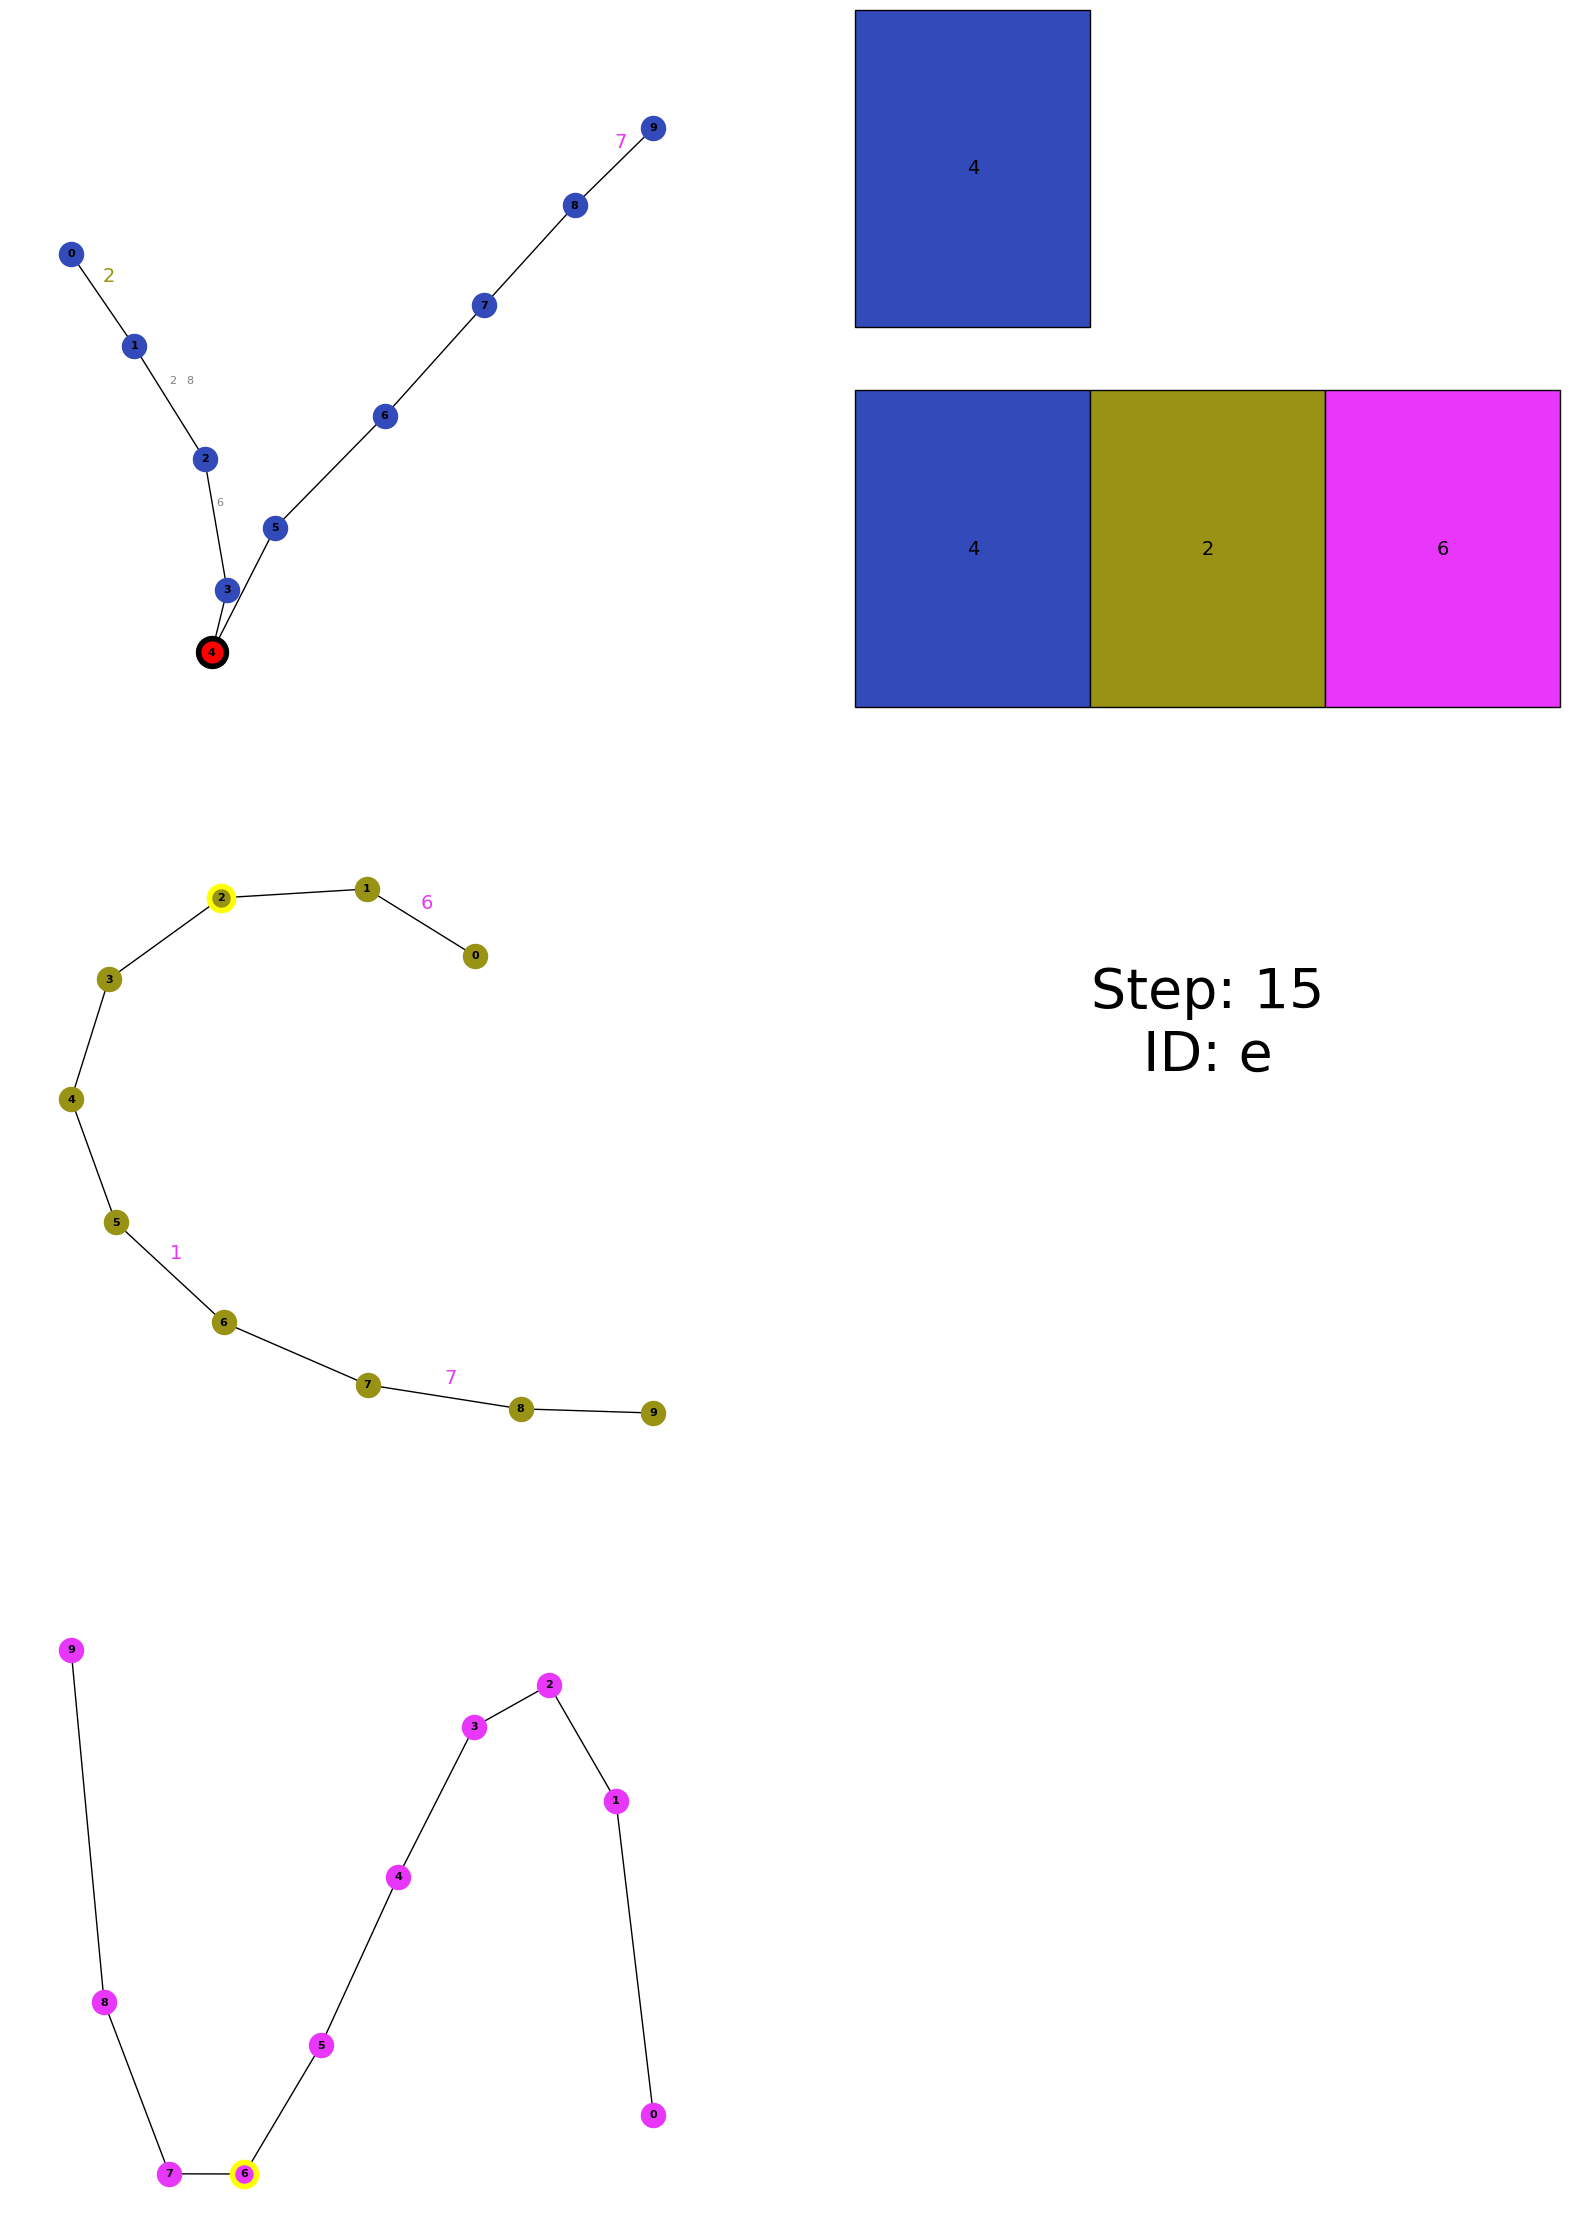

In [34]:
import visualize_search as vs
import importlib

importlib.reload(vs)

visualization = vs.Visualize_search(chains, full_path, sample['input'])
visualization.animate("test_visualization")